<h1>Predicción de tráfico</h1>

<h2>Carga de datos</h2> 

In [1]:
from sklearn import datasets
import pandas as pd
import numpy as np

traffic = pd.read_csv('traffic.csv')
traffic

,DateTime,Junction,Vehicles,ID
0,2015-11-01 00:00:00,1,15,20151101001
1,2015-11-01 01:00:00,1,13,20151101011
2,2015-11-01 02:00:00,1,10,20151101021
3,2015-11-01 03:00:00,1,7,20151101031
4,2015-11-01 04:00:00,1,9,20151101041
...,...,...,...,...
48115,2017-06-30 19:00:00,4,11,20170630194
48116,2017-06-30 20:00:00,4,30,20170630204
48117,2017-06-30 21:00:00,4,16,20170630214
48118,2017-06-30 22:00:00,4,22,20170630224


In [2]:
traffic.isna().sum()

DateTime    0
Junction    0
Vehicles    0
ID          0
dtype: int64

In [3]:
import datetime as dt
traffic['DateTime'] = pd.to_datetime(traffic['DateTime'])

traffic['Hour'] = traffic['DateTime'].dt.hour
traffic['DayOfWeek'] = traffic['DateTime'].dt.dayofweek
traffic['Month'] = traffic['DateTime'].dt.month

traffic['IsWeekend'] = (traffic['DayOfWeek'] >= 5).astype(int)

traffic

,DateTime,Junction,Vehicles,ID,Hour,DayOfWeek,Month,IsWeekend
0,2015-11-01 00:00:00,1,15,20151101001,0,6,11,1
1,2015-11-01 01:00:00,1,13,20151101011,1,6,11,1
2,2015-11-01 02:00:00,1,10,20151101021,2,6,11,1
3,2015-11-01 03:00:00,1,7,20151101031,3,6,11,1
4,2015-11-01 04:00:00,1,9,20151101041,4,6,11,1
...,...,...,...,...,...,...,...,...
48115,2017-06-30 19:00:00,4,11,20170630194,19,4,6,0
48116,2017-06-30 20:00:00,4,30,20170630204,20,4,6,0
48117,2017-06-30 21:00:00,4,16,20170630214,21,4,6,0
48118,2017-06-30 22:00:00,4,22,20170630224,22,4,6,0


In [4]:
traffic.drop(columns=['ID', "DateTime"], inplace=True)

<h2>Codificación</h2>

In [5]:
from sklearn.preprocessing import OneHotEncoder

#cruces = pd.DataFrame(traffic.get('Junction'))

#encoder = OneHotEncoder(drop='first')

#one_hot_encoded = encoder.fit_transform(cruces)

#one_hot_df = pd.DataFrame(one_hot_encoded, columns=encoder.get_feature_names_out())

#df_encoded = pd.concat([traffic, one_hot_df], axis=1)

#traffic_encoded = df_encoded.drop(cruces, axis=1)

#traffic_encoded

#importamos OneHotEncoder
from sklearn.preprocessing import OneHotEncoder

#Creamos el encoder
oneHotEncoder = OneHotEncoder(drop='first');

#Fit the encoder
oneHotEncoderFit = oneHotEncoder.fit(traffic['Junction'].values.reshape(-1,1))

#Trasformar los datos
junction_encoded = oneHotEncoderFit.transform(traffic['Junction'].values.reshape(-1,1)).toarray()

#Agregamos 3 nuevas columnas
traffic[['Junction_2', 'Junction_3', 'Junction_4']] = junction_encoded

#Eliminamos la columna Junction
traffic.drop(['Junction'], axis=1, inplace=True)
traffic_encoded = traffic

<h2>Limpieza</h2>

<h2>Dividimos los datos</h2>

In [6]:
from sklearn.model_selection import train_test_split
target_values = traffic_encoded.get('Vehicles')
traffic_encoded.drop(columns=['Vehicles'], inplace=True)

x_train, x_test, y_train, y_test = train_test_split(traffic_encoded, target_values, train_size = 0.8, random_state = 1234)

x_train

,Hour,DayOfWeek,Month,IsWeekend,Junction_2,Junction_3,Junction_4
37499,11,2,10,0,0.0,1.0,0.0
23481,9,5,11,1,1.0,0.0,0.0
28031,23,5,5,1,1.0,0.0,0.0
38136,0,1,11,0,0.0,1.0,0.0
19256,8,4,5,0,1.0,0.0,0.0
...,...,...,...,...,...,...,...
32399,23,6,3,1,0.0,1.0,0.0
17048,8,3,2,0,1.0,0.0,0.0
23924,20,2,11,0,1.0,0.0,0.0
34086,6,0,5,0,0.0,1.0,0.0


<h2>Predicción de tráfico con KNN</h2>

In [7]:
from sklearn.neighbors import KNeighborsRegressor as KNN

k = int(np.round(np.sqrt(x_train.shape[0])))
knn = KNN(n_neighbors=k)

knn.fit(x_train, y_train)

y_pred_knn = knn.predict(x_test)
y_pred_knn

array([23.09693878, 34.5255102 , 36.14795918, ..., 18.68877551,
       20.66326531, 12.08673469], shape=(9624,))

In [8]:
pd.DataFrame({"Predicciones" :y_pred_knn,"Valores reales": y_test})

,Predicciones,Valores reales
13618,23.096939,49
6996,34.525510,55
43578,36.147959,44
11832,32.244898,68
48068,40.025510,23
...,...,...
11501,18.045918,38
18626,17.183673,6
6175,18.688776,25
30720,20.663265,3


In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score 

print(f'MAE: {mean_absolute_error(y_test, y_pred_knn)}')
print(f'MSE: {mean_squared_error(y_test, y_pred_knn)}')
print(f'R²: {r2_score(y_test, y_pred_knn)}')


MAE: 13.525318294400055
MSE: 315.2600105003959
R²: 0.2539117764756239


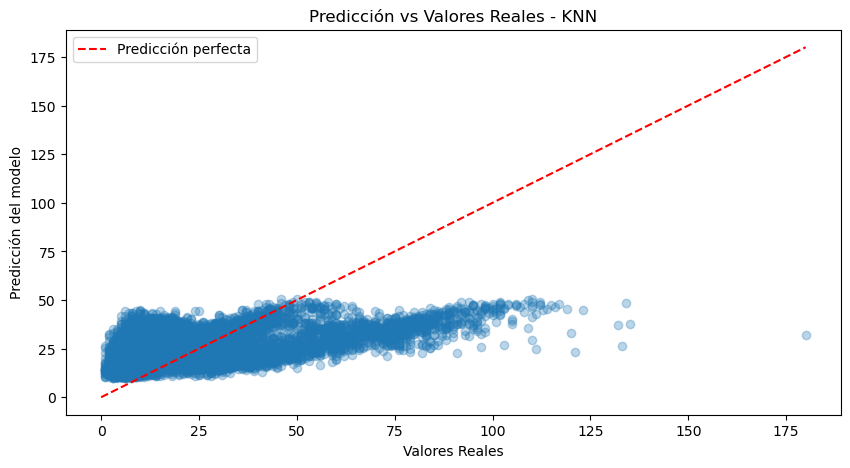

In [10]:
import matplotlib.pyplot as plt
max_val = max(y_test.max(), y_pred_knn.max())

plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred_knn, alpha=0.3)
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', label='Predicción perfecta')
plt.title('Predicción vs Valores Reales - KNN')
plt.xlabel('Valores Reales')
plt.ylabel('Predicción del modelo')
plt.legend()
plt.show()

<h2>Predicción de tráfico con una Red Neuronal</h2>

In [11]:
from sklearn.neural_network import MLPRegressor

# Usaremos un perceptrón multicapa
clf = MLPRegressor(random_state=1, max_iter=500)

clf.fit(x_train, y_train)

y_pred_nn = clf.predict(x_test)
y_pred_nn

C:\Users\Alvi\miniconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:792: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


array([36.35806075, 57.47143463, 20.12361624, ..., 36.41042085,
       12.82269904,  5.82360786], shape=(9624,))

In [12]:
pd.DataFrame({"Predicciones" :y_pred_nn,"Valores reales": y_test})

,Predicciones,Valores reales
13618,36.358061,49
6996,57.471435,55
43578,20.123616,44
11832,50.405979,68
48068,8.066524,23
...,...,...
11501,29.588892,38
18626,12.146997,6
6175,36.410421,25
30720,12.822699,3


In [13]:
clf.score(x_test, y_test)

0.6873655617037565

In [14]:
max_val = max(y_test.max(), y_pred_nn.max())

plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred_nn, alpha=0.3)
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', label='Predicción perfecta')
plt.title('Predicción vs Valores Reales - Perceptrón Multicapa')
plt.xlabel('Valores Reales')
plt.ylabel('Predicción del modelo')
plt.legend()
plt.show()


KeyboardInterrupt



<h2>Predicción de tráfico con Support Vector Machine</h2>

In [ ]:
from sklearn.svm import SVR

svm = SVR(kernel='linear')

svm.fit(x_train, y_train)

y_pred_svm = svm.predict(x_test)
y_pred_svm

In [ ]:
pd.DataFrame({"Predicciones" :y_pred_svm,"Valores reales": y_test})

In [ ]:
svm.score(x_test, y_test)

In [ ]:
max_val = max(y_test.max(), y_pred_svm.max())

plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred_svm, alpha=0.3)
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', label='Predicción perfecta')
plt.title('Predicción vs Valores Reales - Support Vector Machine')
plt.xlabel('Valores Reales')
plt.ylabel('Predicción del modelo')
plt.legend()
plt.show()